## Import Libraries

In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

## Load the saved model

In [18]:
model = tf.keras.models.load_model("models/InceptionV3_model.h5", compile=False)

***Class labels***

In [19]:
class_labels = ['Clams', 'Dolphin', 'Jelly Fish', 'Lobster', 'Nudibranchs']

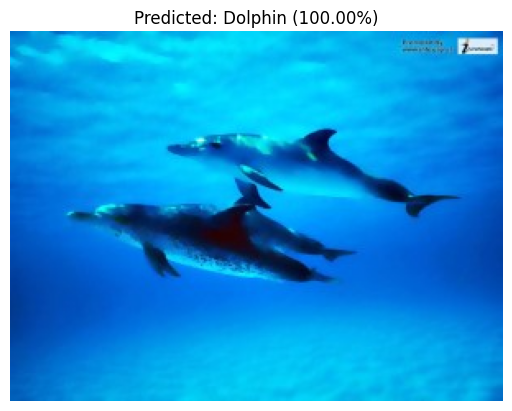

('Dolphin', 99.9995231628418)

In [25]:
def predict_image(image_path):
    try:
        # Load and preprocess image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (128, 128))
        image = image / 255.0  # Normalize
        image = np.expand_dims(image, axis=0)  # Add batch dimension

        # Make prediction
        prediction = model.predict(image)
        predicted_class = class_labels[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # Show image and prediction
        plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
        plt.show()

        return predicted_class, confidence

    except Exception as e:
        print("Error during prediction:", e)

# Test with one image
image_path = "input/Dolphin/10132691013_8d9e263177_o.jpg"  
predict_image(image_path)

---

# Thank you